In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/aug_train.csv")

df.head(10)

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0
5,21651,city_176,0.764,NaN,Has relevent experience,Part time course,Graduate,STEM,11,NaN,NaN,1,24,1.0
6,28806,city_160,0.920,Male,Has relevent experience,no_enrollment,High School,NaN,5,50-99,Funded Startup,1,24,0.0
7,402,city_46,0.762,Male,Has relevent experience,no_enrollment,Graduate,STEM,13,<10,Pvt Ltd,>4,18,1.0
8,27107,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,7,50-99,Pvt Ltd,1,46,1.0
9,699,city_103,0.920,NaN,Has relevent experience,no_enrollment,Graduate,STEM,17,10000+,Pvt Ltd,>4,123,0.0


In [2]:
df.shape


(19158, 14)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  object 
 2   city_development_index  19158 non-null  float64
 3   gender                  14650 non-null  object 
 4   relevent_experience     19158 non-null  object 
 5   enrolled_university     18772 non-null  object 
 6   education_level         18698 non-null  object 
 7   major_discipline        16345 non-null  object 
 8   experience              19093 non-null  object 
 9   company_size            13220 non-null  object 
 10  company_type            13018 non-null  object 
 11  last_new_job            18735 non-null  object 
 12  training_hours          19158 non-null  int64  
 13  target                  19158 non-null  float64
dtypes: float64(2), int64(2), object(10)
me

In [4]:
df.isnull().sum()

enrollee_id                  0
city                         0
city_development_index       0
gender                    4508
relevent_experience          0
enrolled_university        386
education_level            460
major_discipline          2813
experience                  65
company_size              5938
company_type              6140
last_new_job               423
training_hours               0
target                       0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df['target'].value_counts()

target
0.0    14381
1.0     4777
Name: count, dtype: int64

In [7]:
df['target'].value_counts(normalize=True) * 100

target
0.0    75.065247
1.0    24.934753
Name: proportion, dtype: float64

missing values


In [8]:

categorical_cols_with_na = [
    'gender', 'company_size', 'company_type', 
    'major_discipline', 'education_level', 
    'enrolled_university', 'experience', 'last_new_job'
]

for col in categorical_cols_with_na:
    df[col] = df[col].fillna('Unknown')

In [9]:

df['city_development_index'] = df['city_development_index'].fillna(df['city_development_index'].median())
df['training_hours'] = df['training_hours'].fillna(df['training_hours'].median())

cleaning values

In [10]:

df['experience_clean'] = df['experience'].replace({
    '<1': 0,
    '>20': 21,
    'Unknown': -1
}).astype(int)

df['last_new_job_clean'] = df['last_new_job'].replace({
    'never': 0,
    '>4': 5,
    'Unknown': -1
}).astype(int)


print( df.isnull().sum().sum())

0


delete feature

In [11]:
df.drop(columns=['experience'], inplace=True)
df.drop(columns=['last_new_job'], inplace=True)
df.drop(columns=['enrollee_id'], inplace=True)
df.drop(columns=['city'], inplace=True)
print(df.columns)

Index(['city_development_index', 'gender', 'relevent_experience',
       'enrolled_university', 'education_level', 'major_discipline',
       'company_size', 'company_type', 'training_hours', 'target',
       'experience_clean', 'last_new_job_clean'],
      dtype='object')


ordinal incoding


In [12]:

education_map = {
    'Primary School': 0,
    'High School': 1,
    'Graduate': 2,
    'Masters': 3,
    'Phd': 4,
    'Unknown': -1
}
df['education_level'] = df['education_level'].map(education_map)


relevent_map = {
    'No relevent experience': 0,
    'Has relevent experience': 1,
    'Unknown': -1
}
df['relevent_experience'] = df['relevent_experience'].map(relevent_map)


enrolled_map = {
    'no_enrollment': 0,
    'Part time course': 1,
    'Full time course': 2,
    'Unknown': -1
}
df['enrolled_university'] = df['enrolled_university'].map(enrolled_map)

In [13]:
df = pd.get_dummies(df, columns=['gender'], prefix='gender',dtype=int)

In [14]:

df['company_size'] = df['company_size'].astype(str).str.strip()


company_size_map = {
    'Unknown': 0,
    '<10': 1,
    '10-49': 2,
    '50-99': 3,
    '100-500': 4,
    '500-999': 5,
    '1000-4999': 6,
    '5000-9999': 7,
    '10000+': 8
}
df['company_size'] = df['company_size'].map(company_size_map).fillna(0).astype(int)

df = pd.get_dummies(df, columns=['major_discipline', 'company_type'], drop_first=True, dtype=int)

In [15]:
df.head(20)

,city_development_index,relevent_experience,enrolled_university,education_level,company_size,training_hours,target,experience_clean,last_new_job_clean,gender_Female,...,major_discipline_No Major,major_discipline_Other,major_discipline_STEM,major_discipline_Unknown,company_type_Funded Startup,company_type_NGO,company_type_Other,company_type_Public Sector,company_type_Pvt Ltd,company_type_Unknown
0,0.920,1,0,2,0,36,1.0,21,1,0,...,0,0,1,0,0,0,0,0,0,1
1,0.776,0,0,2,3,47,0.0,15,5,0,...,0,0,1,0,0,0,0,0,1,0
2,0.624,0,2,2,0,83,0.0,5,0,0,...,0,0,1,0,0,0,0,0,0,1
3,0.789,0,-1,2,0,52,1.0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
4,0.767,1,0,3,3,8,0.0,21,4,0,...,0,0,1,0,1,0,0,0,0,0
5,0.764,1,1,2,0,24,1.0,11,1,0,...,0,0,1,0,0,0,0,0,0,1
6,0.920,1,0,1,3,24,0.0,5,1,0,...,0,0,0,1,1,0,0,0,0,0
7,0.762,1,0,2,1,18,1.0,13,5,0,...,0,0,1,0,0,0,0,0,1,0
8,0.920,1,0,2,3,46,1.0,7,1,0,...,0,0,1,0,0,0,0,0,1,0
9,0.920,1,0,2,8,123,0.0,17,5,0,...,0,0,1,0,0,0,0,0,1,0


outliers


In [16]:
import numpy as np

num_cols = ['training_hours', 'experience_clean', 'last_new_job_clean', 'city_development_index']

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"{col}: {len(outliers)}")

training_hours: 984
experience_clean: 0
last_new_job_clean: 0
city_development_index: 17


In [17]:
import numpy as np

num_cols = ['training_hours', 'city_development_index']

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])

In [18]:
X = df.drop(columns=['target'])
y = df['target']
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()


X_train_scaled = scaler.fit_transform(X_train)


X_test_scaled = scaler.transform(X_test)

In [19]:
X_train.isnull().sum().sort_values(ascending=False)

city_development_index              0
relevent_experience                 0
enrolled_university                 0
education_level                     0
company_size                        0
training_hours                      0
experience_clean                    0
last_new_job_clean                  0
gender_Female                       0
gender_Male                         0
gender_Other                        0
gender_Unknown                      0
major_discipline_Business Degree    0
major_discipline_Humanities         0
major_discipline_No Major           0
major_discipline_Other              0
major_discipline_STEM               0
major_discipline_Unknown            0
company_type_Funded Startup         0
company_type_NGO                    0
company_type_Other                  0
company_type_Public Sector          0
company_type_Pvt Ltd                0
company_type_Unknown                0
dtype: int64

In [20]:

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_scaled, y_train)

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_scaled, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [21]:
from sklearn.metrics import accuracy_score, classification_report


y_pred_lr = lr_model.predict(X_test_scaled)
y_pred_rf = rf_model.predict(X_test_scaled)

print("================ Logistic Regression ================")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))


print("\n================ Random Forest ================")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

================ Logistic Regression ================
Accuracy: 0.7729645093945721

Classification Report:
               precision    recall  f1-score   support

         0.0       0.80      0.93      0.86      2877
         1.0       0.59      0.29      0.39       955

    accuracy                           0.77      3832
   macro avg       0.69      0.61      0.63      3832
weighted avg       0.75      0.77      0.74      3832


================ Random Forest ================
Accuracy: 0.7776617954070981

Classification Report:
               precision    recall  f1-score   support

         0.0       0.83      0.88      0.86      2877
         1.0       0.56      0.47      0.51       955

    accuracy                           0.78      3832
   macro avg       0.70      0.68      0.69      3832
weighted avg       0.77      0.78      0.77      3832



In [22]:
print("Training set:")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True))

print("\nTest set:")
print(y_test.value_counts())
print(y_test.value_counts(normalize=True))

Training set:
target
0.0    11504
1.0     3822
Name: count, dtype: int64
target
0.0    0.75062
1.0    0.24938
Name: proportion, dtype: float64

Test set:
target
0.0    2877
1.0     955
Name: count, dtype: int64
target
0.0    0.750783
1.0    0.249217
Name: proportion, dtype: float64


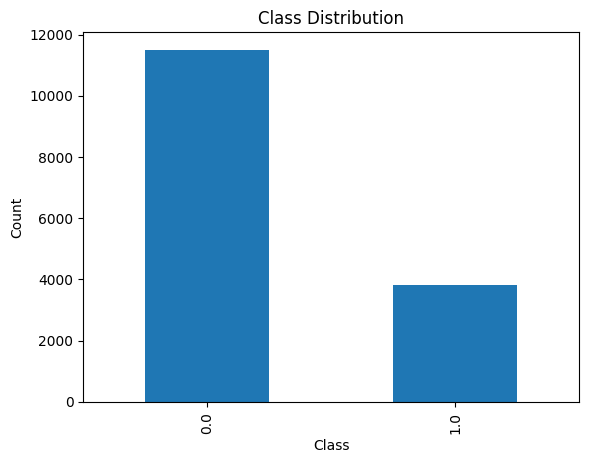

In [23]:
import matplotlib.pyplot as plt

y_train.value_counts().plot(kind='bar')

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [24]:
rf_model_balanced = RandomForestClassifier(
    random_state=42,
    class_weight='balanced'
)

rf_model_balanced.fit(X_train_scaled, y_train)

y_pred_balanced = rf_model_balanced.predict(X_test_scaled)


print("\n================ Random Forest ================")
print("Accuracy:", accuracy_score(y_test, y_pred_balanced))
print("\nClassification Report:\n", classification_report(y_test, y_pred_balanced))


================ Random Forest ================
Accuracy: 0.7771398747390397

Classification Report:
               precision    recall  f1-score   support

         0.0       0.83      0.89      0.86      2877
         1.0       0.57      0.45      0.50       955

    accuracy                           0.78      3832
   macro avg       0.70      0.67      0.68      3832
weighted avg       0.76      0.78      0.77      3832



In [25]:

lr_model_balanced = LogisticRegression(
    random_state=42,
    class_weight='balanced',
    max_iter=1000
)

lr_model_balanced.fit(X_train_scaled, y_train)

y_pred_lr = lr_model_balanced.predict(X_test_scaled)

print("\n================ Logistic Regression ================")

print("Accuracy:", accuracy_score(y_test, y_pred_lr))

print("\nClassification Report:\n",
      classification_report(y_test, y_pred_lr))


================ Logistic Regression ================
Accuracy: 0.7249478079331941

Classification Report:
               precision    recall  f1-score   support

         0.0       0.90      0.71      0.79      2877
         1.0       0.47      0.77      0.58       955

    accuracy                           0.72      3832
   macro avg       0.69      0.74      0.69      3832
weighted avg       0.80      0.72      0.74      3832



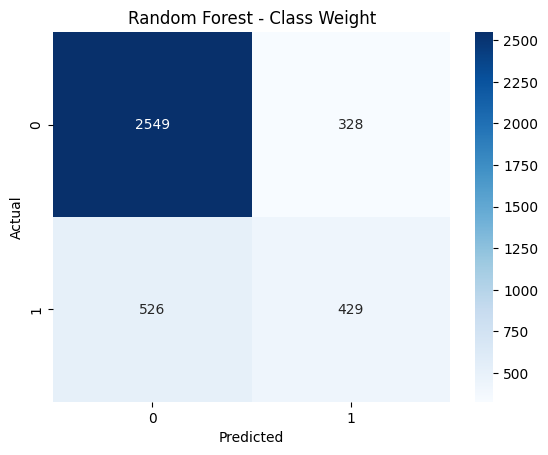

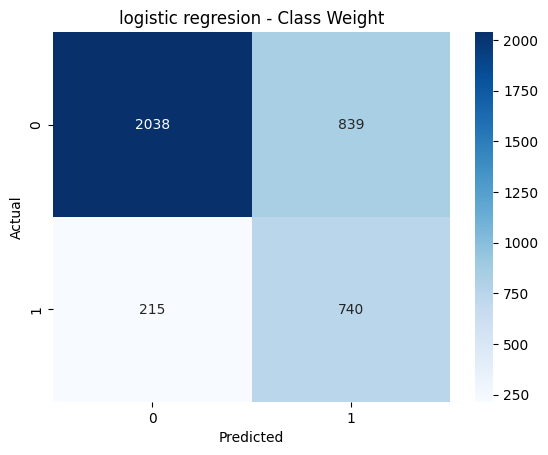

In [26]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_balanced)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest - Class Weight")
plt.show()

cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("logistic regresion - Class Weight")
plt.show()

In [27]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Random Forest
rf_prob = rf_model_balanced.predict_proba(X_test_scaled)[:, 1]

# Logistic Regression
lr_prob = lr_model_balanced.predict_proba(X_test_scaled)[:, 1]

rf_auc = roc_auc_score(y_test, rf_prob)
lr_auc = roc_auc_score(y_test, lr_prob)

print("Random Forest ROC-AUC:", rf_auc)
print("Logistic Regression ROC-AUC:", lr_auc)

Random Forest ROC-AUC: 0.7924008247392663
Logistic Regression ROC-AUC: 0.7827658246391767


In [28]:
from sklearn.metrics import precision_recall_curve, auc

# Random Forest
rf_precision, rf_recall, _ = precision_recall_curve(y_test, rf_prob)
rf_pr_auc = auc(rf_recall, rf_precision)

# Logistic Regression
lr_precision, lr_recall, _ = precision_recall_curve(y_test, lr_prob)
lr_pr_auc = auc(lr_recall, lr_precision)

print("Random Forest PR-AUC:", rf_pr_auc)
print("Logistic Regression PR-AUC:", lr_pr_auc)

Random Forest PR-AUC: 0.5269426452953138
Logistic Regression PR-AUC: 0.5096889931666145


In [29]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model_balanced.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

                             Feature  Importance
0             city_development_index    0.256924
5                     training_hours    0.209240
6                   experience_clean    0.137534
4                       company_size    0.092774
7                 last_new_job_clean    0.070022
3                    education_level    0.041890
2                enrolled_university    0.035273
23              company_type_Unknown    0.034121
1                relevent_experience    0.019032
22              company_type_Pvt Ltd    0.018906
9                        gender_Male    0.011853
16             major_discipline_STEM    0.011123
11                    gender_Unknown    0.010772
17          major_discipline_Unknown    0.008533
21        company_type_Public Sector    0.007068
8                      gender_Female    0.007067
18       company_type_Funded Startup    0.006487
13       major_discipline_Humanities    0.004372
19                  company_type_NGO    0.004054
12  major_discipline

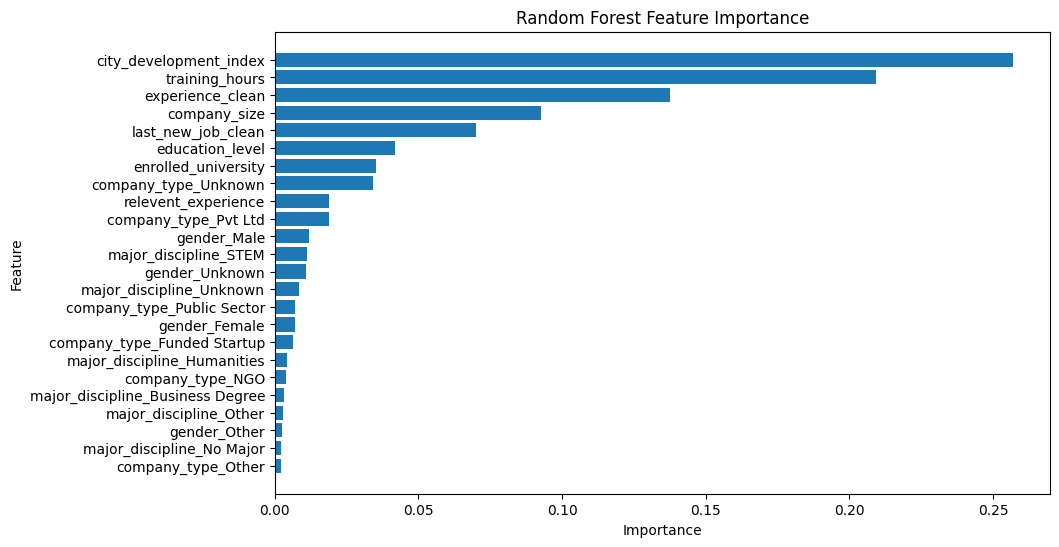

In [30]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()

plt.show()

In [31]:
df_analysis = df.copy()

df_analysis["CDI_Group"] = pd.cut(
    df_analysis["city_development_index"],
    bins=[0, 0.5, 0.7, 0.8, 0.9, 1.0],
    labels=[
        "Very Low",
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

result = df_analysis.groupby("CDI_Group", observed=True)["target"].mean()

print(result)

CDI_Group
Very Low     0.587302
Low          0.509014
Medium       0.246809
High         0.135813
Very High    0.168309
Name: target, dtype: float64


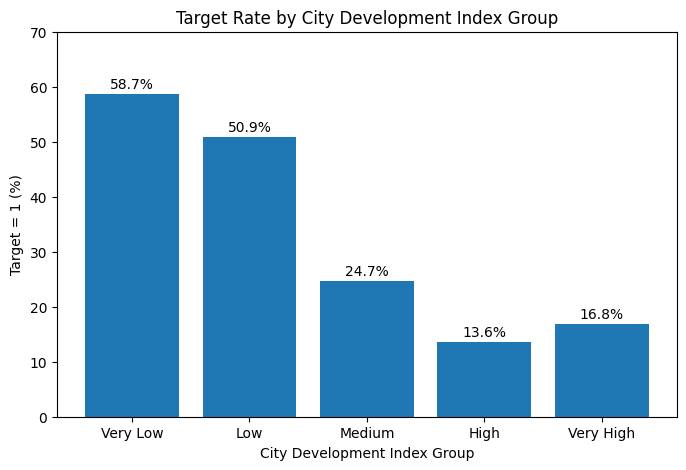

In [45]:
result_percent = (
    df_analysis.groupby("CDI_Group", observed=True)["target"]
    .mean() * 100
)

plt.figure(figsize=(8, 5))

plt.bar(result_percent.index, result_percent.values)

plt.xlabel("City Development Index Group")
plt.ylabel("Target = 1 (%)")
plt.title("Target Rate by City Development Index Group")

for i, value in enumerate(result_percent.values):
    plt.text(i, value + 1, f"{value:.1f}%", ha="center")

plt.ylim(0, 70)
plt.show()

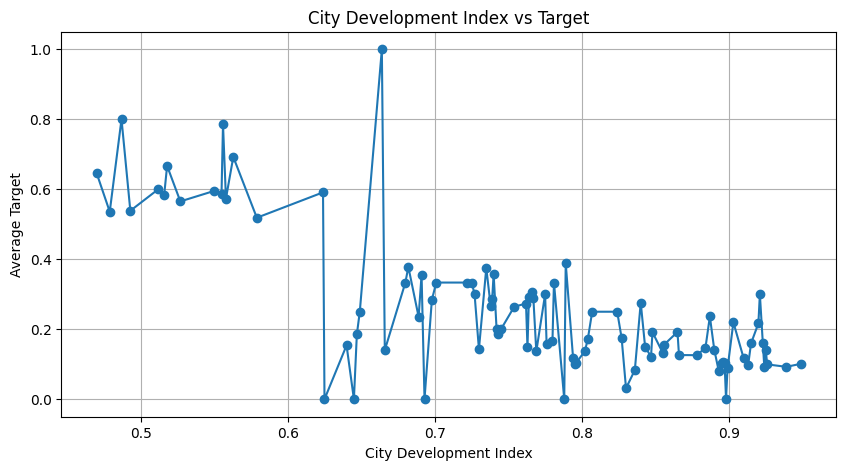

In [44]:
result = df.groupby("city_development_index")["target"].mean()

plt.figure(figsize=(10, 5))

plt.plot(result.index, result.values, marker="o")

plt.xlabel("City Development Index")
plt.ylabel("Average Target")
plt.title("City Development Index vs Target")

plt.grid(True)
plt.show()

In [32]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=10,
    cv=5,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)

rf_random.fit(X_train_scaled, y_train)

best_rf = rf_random.best_estimator_

print("Best Parameters:")
print(rf_random.best_params_)

print("\nBest CV F1 Score:")
print(rf_random.best_score_)

Best Parameters:
{'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 20}

Best CV F1 Score:
0.6199922634798621


In [33]:
from sklearn.metrics import classification_report, accuracy_score

thresholds = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]

y_prob = best_rf.predict_proba(X_test_scaled)[:, 1]

for threshold in thresholds:
    y_pred = (y_prob >= threshold).astype(int)

    print(f"\n================ Threshold = {threshold} ================")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))


================ Threshold = 0.2 ================
Accuracy: 0.5981210855949896
              precision    recall  f1-score   support

         0.0       0.93      0.50      0.65      2877
         1.0       0.37      0.88      0.52       955

    accuracy                           0.60      3832
   macro avg       0.65      0.69      0.59      3832
weighted avg       0.79      0.60      0.62      3832


================ Threshold = 0.25 ================
Accuracy: 0.6863256784968684
              precision    recall  f1-score   support

         0.0       0.92      0.63      0.75      2877
         1.0       0.43      0.84      0.57       955

    accuracy                           0.69      3832
   macro avg       0.68      0.74      0.66      3832
weighted avg       0.80      0.69      0.71      3832


================ Threshold = 0.3 ================
Accuracy: 0.7369519832985386
              precision    recall  f1-score   support

         0.0       0.92      0.71      0.80      2

Final Model: Tuned Random Forest
Threshold: 0.4

Accuracy:
0.7760960334029228

Classification Report:
              precision    recall  f1-score   support

         0.0       0.91      0.78      0.84      2877
         1.0       0.53      0.78      0.63       955

    accuracy                           0.78      3832
   macro avg       0.72      0.78      0.74      3832
weighted avg       0.82      0.78      0.79      3832


Confusion Matrix:
[[2232  645]
 [ 213  742]]


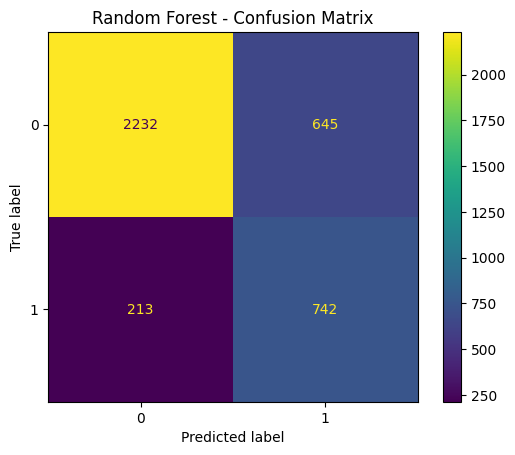

Model saved successfully!


In [ ]:

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

final_model = best_rf
final_threshold = 0.40
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

y_prob = final_model.predict_proba(X_test_scaled)[:, 1]

y_pred_final = (y_prob >= final_threshold).astype(int)

print("Final Model: Tuned Random Forest")
print("Threshold:", final_threshold)

print("\nAccuracy:")
print(accuracy_score(y_test, y_pred_final))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_final))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_final))



cm = confusion_matrix(y_test, y_pred_final)


disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[0, 1]
)

disp.plot()
plt.title("Random Forest - Confusion Matrix")
plt.show()
import joblib

joblib.dump(final_model, "recruitment_model.pkl")

joblib.dump(final_threshold, "threshold.pkl")

print("Model saved successfully!")

In [38]:
feature_names = X_train.columns.tolist()

joblib.dump(feature_names, "feature_names.pkl")

print(feature_names)

['city_development_index', 'relevent_experience', 'enrolled_university', 'education_level', 'company_size', 'training_hours', 'experience_clean', 'last_new_job_clean', 'gender_Female', 'gender_Male', 'gender_Other', 'gender_Unknown', 'major_discipline_Business Degree', 'major_discipline_Humanities', 'major_discipline_No Major', 'major_discipline_Other', 'major_discipline_STEM', 'major_discipline_Unknown', 'company_type_Funded Startup', 'company_type_NGO', 'company_type_Other', 'company_type_Public Sector', 'company_type_Pvt Ltd', 'company_type_Unknown']


In [39]:
print(type(scaler))

<class 'sklearn.preprocessing._data.StandardScaler'>


In [40]:
import joblib

# Feature names
joblib.dump(feature_names, "feature_names.pkl")

# Scaler
joblib.dump(scaler, "scaler.pkl")

print("All files saved successfully!")

All files saved successfully!
